# IMPORT LIBRARIES

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)


# LOAD DATASET

In [12]:
df = pd.read_csv("ICRISAT-District Level Data - ICRISAT-District Level Data (1).csv")
df.head()


,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42


# BASIC INFO

In [13]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16146 entries, 0 to 16145
Data columns (total 80 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Dist Code                                    16146 non-null  int64  
 1   Year                                         16146 non-null  int64  
 2   State Code                                   16146 non-null  int64  
 3   State Name                                   16146 non-null  object 
 4   Dist Name                                    16146 non-null  object 
 5   RICE AREA (1000 ha)                          16146 non-null  float64
 6   RICE PRODUCTION (1000 tons)                  16146 non-null  float64
 7   RICE YIELD (Kg per ha)                       16146 non-null  float64
 8   WHEAT AREA (1000 ha)                         16146 non-null  float64
 9   WHEAT PRODUCTION (1000 tons)                 16146 non-null  float64
 10

Dist Code                               0
Year                                    0
State Code                              0
State Name                              0
Dist Name                               0
                                       ..
VEGETABLES AREA (1000 ha)               0
FRUITS AND VEGETABLES AREA (1000 ha)    0
POTATOES AREA (1000 ha)                 0
ONION AREA (1000 ha)                    0
FODDER AREA (1000 ha)                   0
Length: 80, dtype: int64

# CLEAN COLUMN NAMES

In [14]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("\n","")
df.columns = df.columns.str.replace("  "," ")
df.columns = df.columns.str.replace(" ","_")
df.head()


,Dist_Code,Year,State_Code,State_Name,Dist_Name,RICE_AREA_(1000_ha),RICE_PRODUCTION_(1000_tons),RICE_YIELD_(Kg_per_ha),WHEAT_AREA_(1000_ha),WHEAT_PRODUCTION_(1000_tons),...,SUGARCANE_YIELD_(Kg_per_ha),COTTON_AREA_(1000_ha),COTTON_PRODUCTION_(1000_tons),COTTON_YIELD_(Kg_per_ha),FRUITS_AREA_(1000_ha),VEGETABLES_AREA_(1000_ha),FRUITS_AND_VEGETABLES_AREA_(1000_ha),POTATOES_AREA_(1000_ha),ONION_AREA_(1000_ha),FODDER_AREA_(1000_ha)
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42


# SAVE CLEAN DATASET

In [15]:
df_clean = df.copy()
df_clean.to_csv("cleaned_agri_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


# TOP 10 RICE PRODUCING STATES

In [6]:
rice_col = "RICE_PRODUCTION_(1000_tons)"
state_col = "State_Name"

top_rice = df_clean.groupby(state_col)[rice_col].sum().sort_values(ascending=False).head(10)

plt.bar(top_rice.index, top_rice.values)
plt.xticks(rotation=45)
plt.title("Top 10 Rice Producing States")
plt.ylabel("Production (1000 tons)")
plt.show()


NameError: name 'df_clean' is not defined

# TOP 10 WHEAT PRODUCING STATES

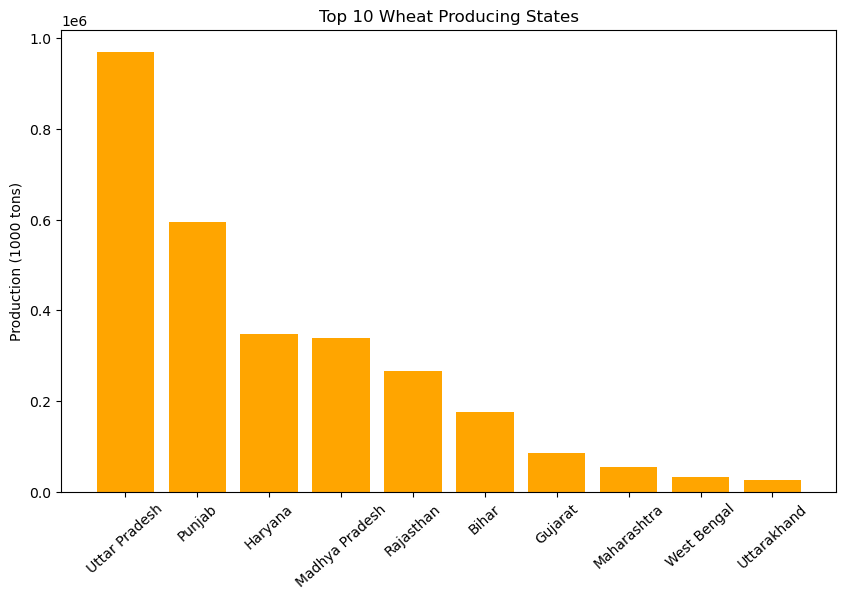

In [19]:
wheat_col = "WHEAT_PRODUCTION_(1000_tons)"

top_wheat = df_clean.groupby(state_col)[wheat_col].sum().sort_values(ascending=False).head(10)

plt.bar(top_wheat.index, top_wheat.values, color='orange')
plt.xticks(rotation=42)
plt.title("Top 10 Wheat Producing States")
plt.ylabel("Production (1000 tons)")
plt.show()


# SUGARCANE 50 YEAR TREND

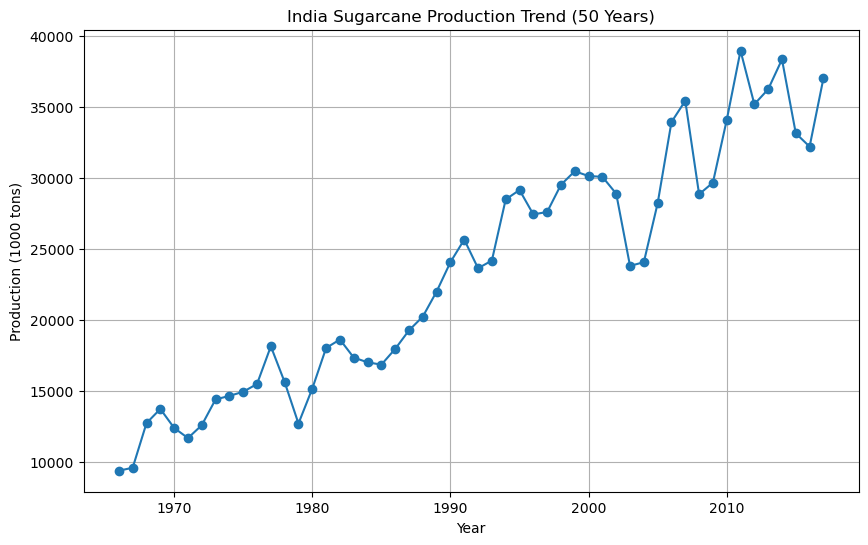

In [20]:
sugar_col = "SUGARCANE_PRODUCTION_(1000_tons)"
year_col = "Year"

sugar_year = df_clean.groupby(year_col)[sugar_col].sum()

plt.plot(sugar_year.index, sugar_year.values, marker='o')
plt.title("India Sugarcane Production Trend (50 Years)")
plt.xlabel("Year")
plt.ylabel("Production (1000 tons)")
plt.grid(True)
plt.show()


# RICE VS WHEAT (50 YEARS)

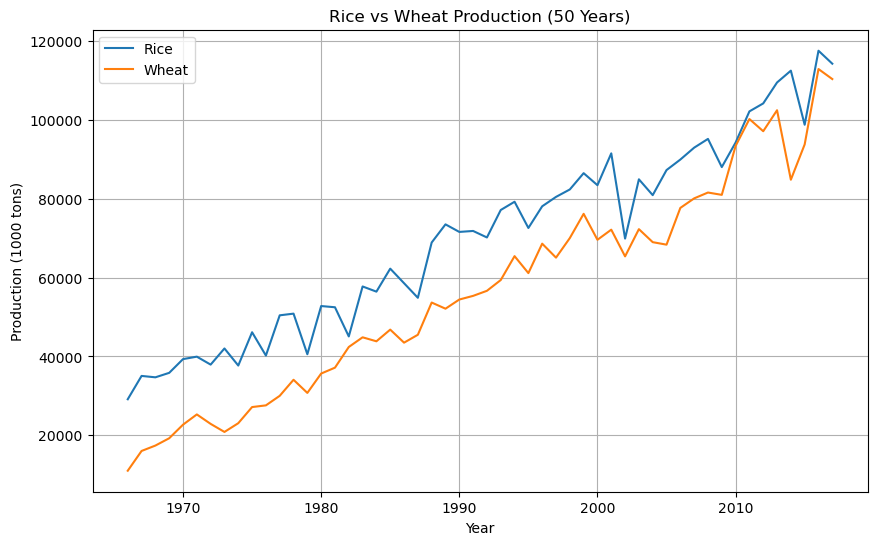

In [22]:
rice_year = df_clean.groupby(year_col)[rice_col].sum()
wheat_year = df_clean.groupby(year_col)[wheat_col].sum()

plt.plot(rice_year.index, rice_year.values, label="Rice")
plt.plot(wheat_year.index, wheat_year.values, label="Wheat")
plt.title("Rice vs Wheat Production (50 Years)")
plt.xlabel("Year")
plt.ylabel("Production (1000 tons)")
plt.legend()
plt.grid(True)
plt.show()


# RICE AREA VS PRODUCTION CORRELATION

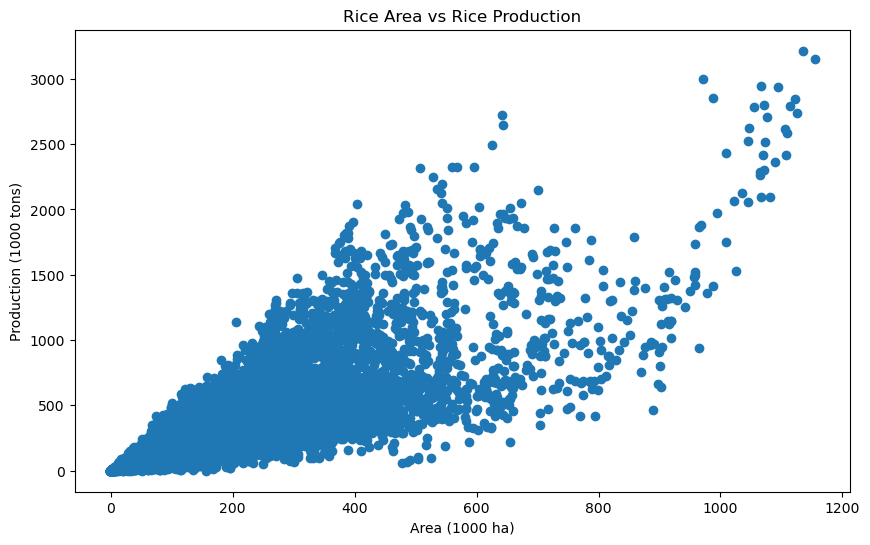

Correlation:  0.8325153171810161


In [23]:
rice_area = "RICE_AREA_(1000_ha)"

plt.scatter(df_clean[rice_area], df_clean[rice_col])
plt.title("Rice Area vs Rice Production")
plt.xlabel("Area (1000 ha)")
plt.ylabel("Production (1000 tons)")
plt.show()

print("Correlation: ", df_clean[rice_area].corr(df_clean[rice_col]))


# SAVE ALL GRAPHS AUTOMATICALLY

All graphs saved inside 'graphs' folder!


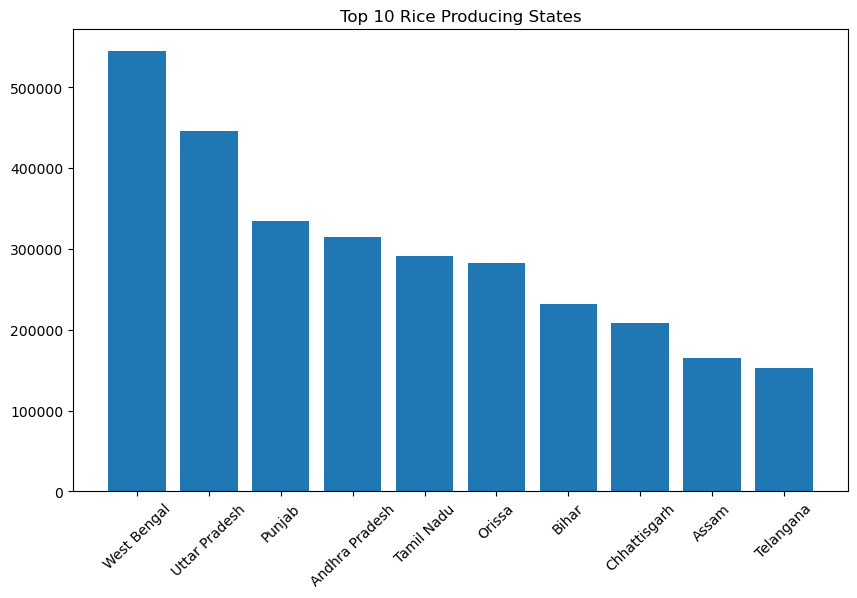

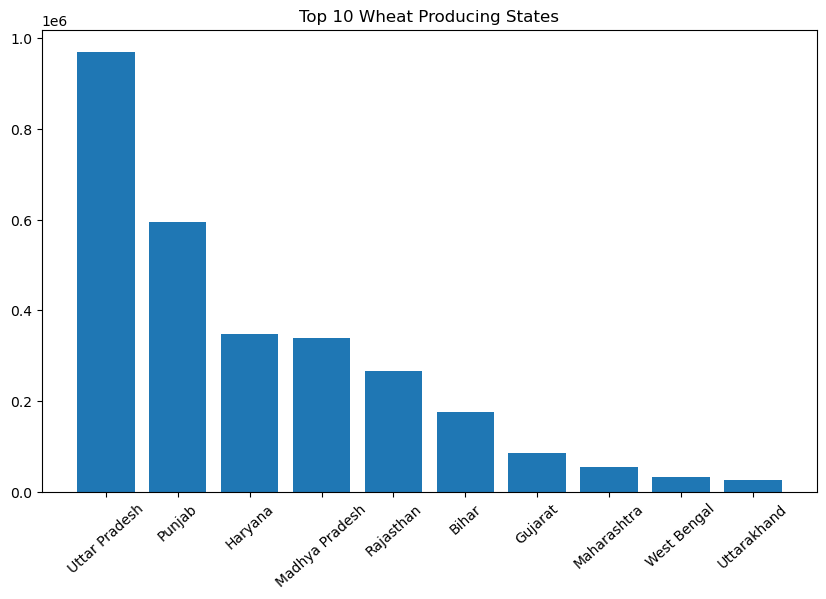

In [25]:
import os

if not os.path.exists("graphs"):
    os.mkdir("graphs")

# Rice
plt.figure()
plt.bar(top_rice.index, top_rice.values)
plt.xticks(rotation=44)
plt.title("Top 10 Rice Producing States")
plt.savefig("graphs/top10_rice_states.png", bbox_inches='tight')

# Wheat
plt.figure()
plt.bar(top_wheat.index, top_wheat.values)
plt.xticks(rotation=42)
plt.title("Top 10 Wheat Producing States")
plt.savefig("graphs/top10_wheat_states.png", bbox_inches='tight')

print("All graphs saved inside 'graphs' folder!")
